In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler
import warnings
from pandas import MultiIndex #, Int64Index # changed
warnings.filterwarnings('ignore')
import os

In [93]:
df = pd.read_pickle("data_Diabetes2.pkl")

In [94]:
print(df.head(10))

   Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0      148             72             35        0  33.6   
1       85             66             29        0  26.6   
2      183             64              0        0  23.3   
3       89             66             23       94  28.1   
4      137             40             35      168  43.1   
5      116             74              0        0  25.6   
6       78             50             32       88  31.0   
7      115              0              0        0  35.3   
8      197             70             45      543  30.5   
9      125             96              0        0   0.0   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
5                     0.201   30        0  
6                     0.248   26        1 

In [95]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Glucose                   768 non-null    int16  
 1   BloodPressure             768 non-null    int8   
 2   SkinThickness             768 non-null    int8   
 3   Insulin                   768 non-null    int16  
 4   BMI                       768 non-null    float64
 5   DiabetesPedigreeFunction  768 non-null    float64
 6   Age                       768 non-null    int8   
 7   Outcome                   768 non-null    int8   
dtypes: float64(2), int16(2), int8(4)
memory usage: 18.1 KB
None


# 5. Label encoding + Data split: train + test


### Test-train split
- Now we split the DS in train and test. The train size is 66%, and the rest is test DS.

- By randomly rearranging the data points(i.e. shuffling), you can avoid biases, improve generalization, and make your models more robust


In [96]:
X = df[["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]]
y = df["Outcome"]

print(X)
print(y)

     Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0        148             72             35        0  33.6   
1         85             66             29        0  26.6   
2        183             64              0        0  23.3   
3         89             66             23       94  28.1   
4        137             40             35      168  43.1   
..       ...            ...            ...      ...   ...   
763      101             76             48      180  32.9   
764      122             70             27        0  36.8   
765      121             72             23      112  26.2   
766      126             60              0        0  30.1   
767       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  
2                       0.672   32  
3                       0.167   21  
4                       2.288   33  
..                        ...  ...  
763     

In [129]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y, train_size=0.66, shuffle=True, random_state=42)

In [130]:
print(X_train.shape)
print(X_test.shape)

(506, 7)
(262, 7)


# 6. Data Preprocessing and Feature Engineering


## Missing Value Treatment
Skip for now

## Scaling continuous variables
- Standardization involves scaling the features such that they have a mean of 0 and a standard deviation of 1. This is useful when features have different units or magnitudes and ensures they are treated equally when used in machine learning models.

- method scaler.fit_transform(df_X) does two things:

fit() computes the mean and standard deviation of each column (feature) in df_X to understand the distribution of the data.

transform() scales each feature in df_X by subtracting the mean and dividing by the standard deviation, effectively standardizing each feature.

In [131]:
scaler = StandardScaler()
# X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_copy),columns=X_train_copy.columns)
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [132]:
print(X_train_scaled)

[[-1.11896686  0.44755979 -1.33159583 ... -0.10414142 -0.25723968
   0.75826946]
 [-1.05738687 -0.5500845  -0.16911382 ... -1.33174556 -0.07548424
  -1.0362453 ]
 [-0.47237695  0.55840916 -1.33159583 ... -1.09667243 -0.9754668
   0.92917563]
 ...
 [-0.62632693  0.89095725  1.05795053 ...  1.77644363  1.95314095
   0.41645712]
 [ 0.6052729  -3.87556548 -1.33159583 ...  1.35853584 -0.77612213
  -0.35262063]
 [ 0.11263297  1.44520408 -1.33159583 ... -1.24032823 -0.60902439
  -1.0362453 ]]


# 7. Modeling + Training


### Logistic Regression

In [138]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import classification_report

lr = LogisticRegression(random_state=16)
lr.fit(X_train_scaled, Y_train)
Y_pred = lr.predict(X_test_scaled)

confusion_matrix = metrics.confusion_matrix(Y_test, Y_pred)
print("-"*70)
print("Report")
print("-"*70)
print("Confusion Matrix:")
print(str(confusion_matrix))
target_names = ['without diabetes', 'with diabetes']
acc=(confusion_matrix[0][0] + confusion_matrix[1][1])/(confusion_matrix[0][0]+confusion_matrix[0][1]+confusion_matrix[1][0]+confusion_matrix[1][1])
print("Accuracy by confusion matrix: "+str(acc))
print("\n")
print(classification_report(Y_test, Y_pred, target_names=target_names))
print("-"*70)

----------------------------------------------------------------------
Report
----------------------------------------------------------------------
Confusion Matrix:
[[144  30]
 [ 37  51]]
Accuracy by confusion matrix: 0.7442748091603053


                  precision    recall  f1-score   support

without diabetes       0.80      0.83      0.81       174
   with diabetes       0.63      0.58      0.60        88

        accuracy                           0.74       262
       macro avg       0.71      0.70      0.71       262
    weighted avg       0.74      0.74      0.74       262

----------------------------------------------------------------------


### Naive Bayes

In [137]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(X_train_scaled, Y_train)
Y_pred = gnb.predict(X_test_scaled)

confusion_matrix = metrics.confusion_matrix(Y_test, Y_pred)
print("-"*70)
print("Report")
print("-"*70)
print("Confusion Matrix:")
print(str(confusion_matrix))
target_names = ['without diabetes', 'with diabetes']
acc=(confusion_matrix[0][0] + confusion_matrix[1][1])/(confusion_matrix[0][0]+confusion_matrix[0][1]+confusion_matrix[1][0]+confusion_matrix[1][1])
print("Accuracy by confusion matrix: "+str(acc))
print("\n")
print(classification_report(Y_test, Y_pred, target_names=target_names))
print("-"*70)

----------------------------------------------------------------------
Report
----------------------------------------------------------------------
Confusion Matrix:
[[141  33]
 [ 39  49]]
Accuracy by confusion matrix: 0.7251908396946565


                  precision    recall  f1-score   support

without diabetes       0.78      0.81      0.80       174
   with diabetes       0.60      0.56      0.58        88

        accuracy                           0.73       262
       macro avg       0.69      0.68      0.69       262
    weighted avg       0.72      0.73      0.72       262

----------------------------------------------------------------------


### K-nearest neighbors

In [139]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, Y_train)
Y_pred = knn.predict(X_test_scaled)

confusion_matrix = metrics.confusion_matrix(Y_test, Y_pred)
print("-"*70)
print("Report")
print("-"*70)
print("Confusion Matrix:")
print(str(confusion_matrix))
target_names = ['without diabetes', 'with diabetes']
acc=(confusion_matrix[0][0] + confusion_matrix[1][1])/(confusion_matrix[0][0]+confusion_matrix[0][1]+confusion_matrix[1][0]+confusion_matrix[1][1])
print("Accuracy by confusion matrix: "+str(acc))
print("\n")
print(classification_report(Y_test, Y_pred, target_names=target_names))
print("-"*70)

----------------------------------------------------------------------
Report
----------------------------------------------------------------------
Confusion Matrix:
[[136  38]
 [ 39  49]]
Accuracy by confusion matrix: 0.7061068702290076


                  precision    recall  f1-score   support

without diabetes       0.78      0.78      0.78       174
   with diabetes       0.56      0.56      0.56        88

        accuracy                           0.71       262
       macro avg       0.67      0.67      0.67       262
    weighted avg       0.71      0.71      0.71       262

----------------------------------------------------------------------


### Decision tree Classifier

In [140]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, Y_train)
Y_pred = dt.predict(X_test_scaled)

confusion_matrix = metrics.confusion_matrix(Y_test, Y_pred)
print("-"*70)
print("Report")
print("-"*70)
print("Confusion Matrix:")
print(str(confusion_matrix))
target_names = ['without diabetes', 'with diabetes']
acc=(confusion_matrix[0][0] + confusion_matrix[1][1])/(confusion_matrix[0][0]+confusion_matrix[0][1]+confusion_matrix[1][0]+confusion_matrix[1][1])
print("Accuracy by confusion matrix: "+str(acc))
print("\n")
print(classification_report(Y_test, Y_pred, target_names=target_names))
print("-"*70)

----------------------------------------------------------------------
Report
----------------------------------------------------------------------
Confusion Matrix:
[[128  46]
 [ 31  57]]
Accuracy by confusion matrix: 0.7061068702290076


                  precision    recall  f1-score   support

without diabetes       0.81      0.74      0.77       174
   with diabetes       0.55      0.65      0.60        88

        accuracy                           0.71       262
       macro avg       0.68      0.69      0.68       262
    weighted avg       0.72      0.71      0.71       262

----------------------------------------------------------------------


### Support Vector Classifier

In [141]:
from sklearn import svm

svm = svm.SVC(kernel='poly') 
svm.fit(X_train_scaled, Y_train)
Y_pred = svm.predict(X_test_scaled)

confusion_matrix = metrics.confusion_matrix(Y_test, Y_pred)
print("-"*70)
print("Report")
print("-"*70)
print("Confusion Matrix:")
print(str(confusion_matrix))
target_names = ['without diabetes', 'with diabetes']
acc=(confusion_matrix[0][0] + confusion_matrix[1][1])/(confusion_matrix[0][0]+confusion_matrix[0][1]+confusion_matrix[1][0]+confusion_matrix[1][1])
print("Accuracy by confusion matrix: "+str(acc))
print("\n")
print(classification_report(Y_test, Y_pred, target_names=target_names))
print("-"*70)

----------------------------------------------------------------------
Report
----------------------------------------------------------------------
Confusion Matrix:
[[156  18]
 [ 51  37]]
Accuracy by confusion matrix: 0.7366412213740458


                  precision    recall  f1-score   support

without diabetes       0.75      0.90      0.82       174
   with diabetes       0.67      0.42      0.52        88

        accuracy                           0.74       262
       macro avg       0.71      0.66      0.67       262
    weighted avg       0.73      0.74      0.72       262

----------------------------------------------------------------------


### Random Forest Classifier

In [142]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=200,random_state=42)
rfc.fit(X_train_scaled, Y_train)

Y_pred = rfc.predict(X_test_scaled)
confusion_matrix = metrics.confusion_matrix(Y_test, Y_pred)
print("-"*70)
print("Report")
print("-"*70)
print("Confusion Matrix:")
print(str(confusion_matrix))
target_names = ['without diabetes', 'with diabetes']
acc=(confusion_matrix[0][0] + confusion_matrix[1][1])/(confusion_matrix[0][0]+confusion_matrix[0][1]+confusion_matrix[1][0]+confusion_matrix[1][1])
print("Accuracy by confusion matrix: "+str(acc))
print("\n")
print(classification_report(Y_test, Y_pred, target_names=target_names))
print("-"*70)

----------------------------------------------------------------------
Report
----------------------------------------------------------------------
Confusion Matrix:
[[138  36]
 [ 30  58]]
Accuracy by confusion matrix: 0.7480916030534351


                  precision    recall  f1-score   support

without diabetes       0.82      0.79      0.81       174
   with diabetes       0.62      0.66      0.64        88

        accuracy                           0.75       262
       macro avg       0.72      0.73      0.72       262
    weighted avg       0.75      0.75      0.75       262

----------------------------------------------------------------------


### conclusion
Accuracy for each of above models:
- Log regression : 74.4%
- Naive Bayes    : 70.9%
- KNN            : 69.0%
- Decision Tree  : 70.2%
- SVC            : 72.9%
- Random Frst. Cl: 74.8%

**It seems RFC does better among all, and next best model is Log Regression.**
**Lets keep RFC.**

Index(['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI',
       'DiabetesPedigreeFunction', 'Age'],
      dtype='object')


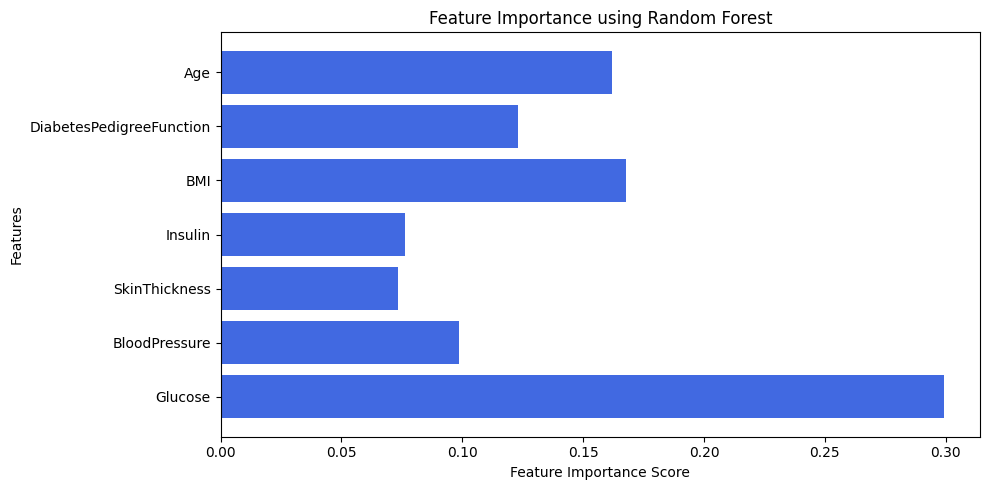

In [146]:
# Lets read Feature Importance
importances = rfc.feature_importances_
feature_names = df.columns
print(feature_names)

# Plot Feature Importance
plt.figure(figsize=(10, 5))
plt.barh(feature_names, importances, color='royalblue')
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance using Random Forest")
plt.show()

It seems that RFC views Glucose most important feature, and then there is BMI, Age and DiabetesPedigreeFunction. Visualizing feature importance helps us identify which features influence the model’s predictions most.

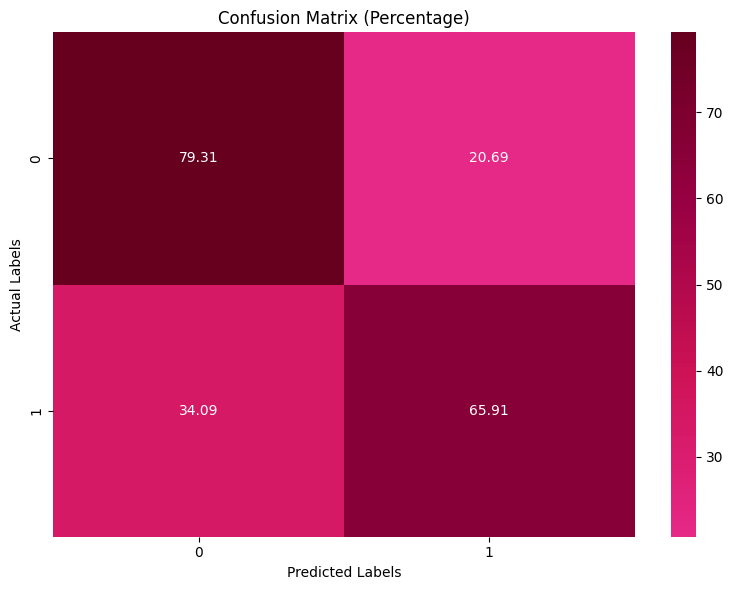

In [149]:
Y_pred = rfc.predict(X_test_scaled)
conf_matrix = metrics.confusion_matrix(Y_test, Y_pred)

# Convert to percentages
conf_matrix_percent = conf_matrix.astype('float') / conf_matrix.sum(axis=1, keepdims=True) * 100

# Define class labels
class_names = np.unique(Y_test)  # Extract unique class names


# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_percent, # or use conf_matrix if you want to see the actual numbers
            annot=True, fmt=".2f",
            cmap='PuRd', center=0,
            xticklabels=class_names,
            yticklabels=class_names)

# Labels and title
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.title("Confusion Matrix (Percentage)")
plt.show()

## Lets save the model

In [148]:
import pickle
pickle.dump(rfc, open('rfc.pkl','wb')) #Save the model for future